# 離散確率分布

In [ ]:
# 視覚化保存用ヘルパー
from pathlib import Path
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import PillowWriter
from IPython.display import HTML, display
import plotly.graph_objects as go


def resolve_chapter2_output_root():
    cwd = Path.cwd().resolve()
    nested = cwd / "ベイズ推論による機械学習入門" / "Chapter2-基本的な確率分布"
    if nested.exists():
        return nested
    if cwd.name == "Chapter2-基本的な確率分布":
        return cwd
    return nested


CHAPTER2_OUTPUT_ROOT = resolve_chapter2_output_root()


def ensure_output_dir(distribution_name):
    output_dir = CHAPTER2_OUTPUT_ROOT / distribution_name
    output_dir.mkdir(parents=True, exist_ok=True)
    return output_dir


def save_figure_png(fig, distribution_name, filename, *, dpi=150):
    output_path = ensure_output_dir(distribution_name) / filename
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Saved PNG: {output_path}")
    return output_path


def save_animation_gif(anim, distribution_name, filename, *, fps=10, dpi=100):
    output_path = ensure_output_dir(distribution_name) / filename
    anim.save(output_path, writer=PillowWriter(fps=fps), dpi=dpi)
    print(f"Saved GIF: {output_path}")
    return output_path


def save_plotly_html(fig, distribution_name, filename):
    output_path = ensure_output_dir(distribution_name) / filename
    fig.write_html(output_path, include_plotlyjs="cdn")
    print(f"Saved HTML: {output_path}")
    return output_path


def build_plotly_preview_figure(fig):
    if fig.frames:
        # 中間フレームを代表フレームとして保存
        frame = fig.frames[len(fig.frames) // 2]
        preview = go.Figure(data=frame.data, layout=deepcopy(fig.layout))
        if frame.layout:
            preview.update_layout(frame.layout)
    else:
        preview = go.Figure(fig)
    preview.update_layout(updatemenus=[], sliders=[])
    return preview


def save_plotly_png(fig, distribution_name, filename, *, scale=2):
    output_path = ensure_output_dir(distribution_name) / filename
    try:
        fig.write_image(output_path, scale=scale)
    except Exception as exc:
        raise RuntimeError(
            "Plotly PNG export requires kaleido==0.2.1. Install it and rerun the notebook."
        ) from exc
    print(f"Saved PNG: {output_path}")
    return output_path


def save_plotly_animation_preview(fig, distribution_name, filename, *, scale=2):
    preview = build_plotly_preview_figure(fig)
    return save_plotly_png(preview, distribution_name, filename, scale=scale)


## ベルヌーイ分布

Saved PNG: /home/njz/study_bayes/ベイズ推論による機械学習入門/Chapter2-基本的な確率分布/bernoulli/empirical_vs_theoretical.png


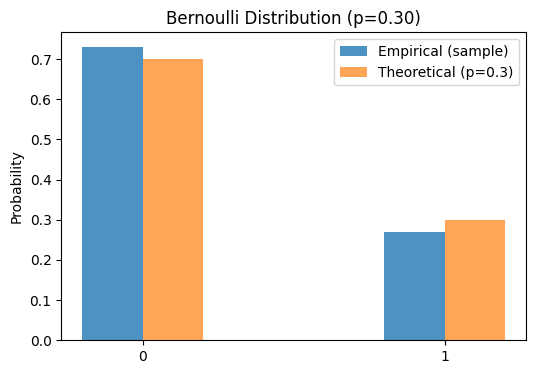

In [2]:
# セル1: Bernoulli の経験分布 vs 理論 PMF
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli

p = 0.3
N = 100

# サンプル（SciPy の rvs でも良いが、ここではNumPy RNGを使う）
rng = np.random.default_rng(42)
samples = rng.binomial(1, p, size=N)  # Bernoulli は n=1 の binomial と同じ

# 経験確率
values, counts = np.unique(samples, return_counts=True)
probs = counts / N

# 理論 PMF（scipy）
k = np.array([0, 1])
theoretical = bernoulli.pmf(k, p)  # [P(X=0), P(X=1)]

# 描画
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(values - 0.1, probs, width=0.2, label="Empirical (sample)", alpha=0.8)
ax.bar(k + 0.1, theoretical, width=0.2, label=f"Theoretical (p={p})", alpha=0.7)

ax.set_xticks([0, 1])
ax.set_xticklabels(["0", "1"])
ax.set_ylabel("Probability")
ax.set_title("Bernoulli Distribution (p={:.2f})".format(p))
ax.legend()
save_figure_png(fig, "bernoulli", "empirical_vs_theoretical.png")
plt.show()


Saved GIF: /home/njz/study_bayes/ベイズ推論による機械学習入門/Chapter2-基本的な確率分布/bernoulli/parameter_sweep.gif


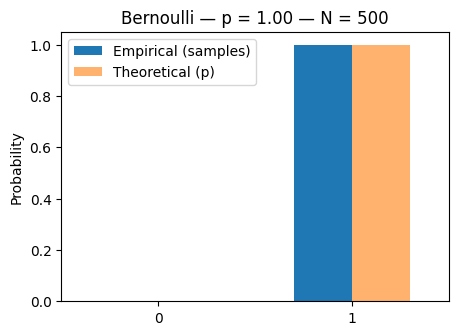

In [3]:
# セル2: p を動かすアニメーション（Notebook 内表示）
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.stats import bernoulli

p_values = np.linspace(0.0, 1.0, 41)
N_anim = 500  # 各フレームでのサンプル数

fig_anim, ax_anim = plt.subplots(figsize=(5, 3.5))
ax_anim.set_xlim(-0.5, 1.5)
ax_anim.set_ylim(0, 1.05)
ax_anim.set_xticks([0, 1])
ax_anim.set_xticklabels(["0", "1"])
ax_anim.set_ylabel("Probability")
title = ax_anim.set_title("")

# 棒の準備（左: 経験, 右: 理論）
x_emp = np.array([0, 1]) - 0.15
x_theo = np.array([0, 1]) + 0.15
width = 0.3
emp_bars = ax_anim.bar(x_emp, [0, 0], width=width)
theo_bars = ax_anim.bar(x_theo, [0, 0], width=width, alpha=0.6)
ax_anim.legend(["Empirical (samples)", "Theoretical (p)"])

rng = np.random.default_rng(123)  # 再現性（サンプリング用）


def update(frame):
    p = p_values[frame]
    # サンプル：Bernoulli は binomial(n=1) と同義
    samples = rng.binomial(1, p, size=N_anim)
    values, counts = np.unique(samples, return_counts=True)
    probs = np.zeros(2)
    probs[values.astype(int)] = counts / N_anim

    # SciPy で理論 PMF
    theo = bernoulli.pmf(np.array([0, 1]), p)

    # 棒の高さ更新
    for rect, h in zip(emp_bars, probs):
        rect.set_height(h)
    for rect, h in zip(theo_bars, theo):
        rect.set_height(h)
    title.set_text(f"Bernoulli — p = {p:.2f} — N = {N_anim}")
    return list(emp_bars) + list(theo_bars) + [title]


anim = FuncAnimation(fig_anim, update, frames=len(p_values), interval=120, blit=True)
save_animation_gif(anim, "bernoulli", "parameter_sweep.gif")
display(HTML(anim.to_jshtml()))


Saved PNG: /home/njz/study_bayes/ベイズ推論による機械学習入門/Chapter2-基本的な確率分布/bernoulli/convergence.png


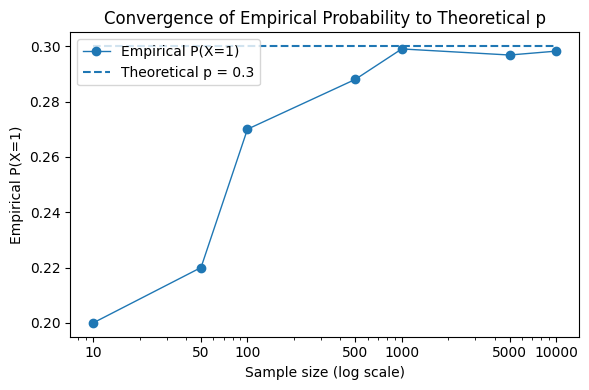

In [4]:
# セル3: 収束確認（経験 P(X=1) -> 理論 p）
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli

p_fixed = 0.3
sample_sizes = [10, 50, 100, 500, 1000, 5000, 10000]
empirical_probs = []

rng = np.random.default_rng(12345)

for n in sample_sizes:
    samples = rng.binomial(1, p_fixed, size=n)
    empirical_probs.append(samples.mean())

fig_conv, ax_conv = plt.subplots(figsize=(6, 4))
ax_conv.plot(
    sample_sizes, empirical_probs, marker="o", linewidth=1, label="Empirical P(X=1)"
)
ax_conv.hlines(
    p_fixed,
    sample_sizes[0],
    sample_sizes[-1],
    linestyles="dashed",
    label=f"Theoretical p = {p_fixed}",
)
ax_conv.set_xscale("log")
ax_conv.set_xlabel("Sample size (log scale)")
ax_conv.set_ylabel("Empirical P(X=1)")
ax_conv.set_title("Convergence of Empirical Probability to Theoretical p")
ax_conv.set_xticks(sample_sizes)
ax_conv.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax_conv.legend()
plt.tight_layout()
save_figure_png(fig_conv, "bernoulli", "convergence.png")
plt.show()


## 二項分布

Saved PNG: /home/njz/study_bayes/ベイズ推論による機械学習入門/Chapter2-基本的な確率分布/binomial/pmf.png


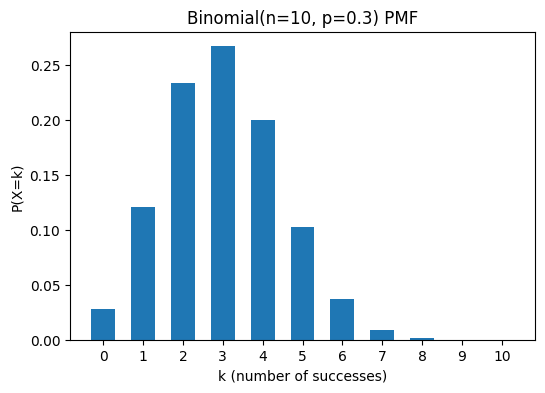

In [5]:
# === セル1: 理論 PMF を描く（単純確認用） ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n = 10
p = 0.3
k = np.arange(n + 1)

# PMF を SciPy で計算
pmf = binom.pmf(k, n, p)

plt.figure(figsize=(6, 4))
plt.bar(k, pmf, width=0.6)
plt.xlabel("k (number of successes)")
plt.ylabel("P(X=k)")
plt.title(f"Binomial(n={n}, p={p}) PMF")
plt.xticks(k)
save_figure_png(plt.gcf(), "binomial", "pmf.png")
plt.show()


Saved GIF: /home/njz/study_bayes/ベイズ推論による機械学習入門/Chapter2-基本的な確率分布/binomial/parameter_sweep.gif


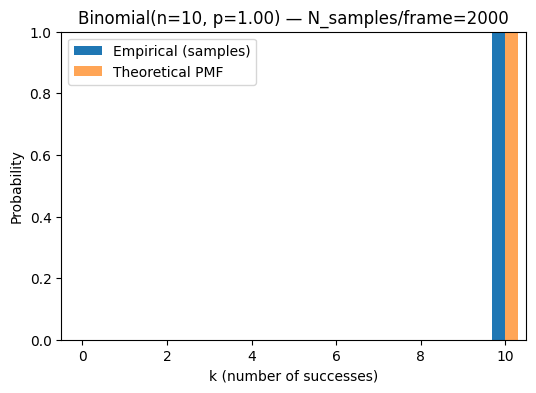

In [6]:
# === セル2: p をスイープするアニメーション（Notebook 内表示用, SciPy版） ===
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.stats import binom

# パラメータ
n = 10
p_values = np.linspace(0.0, 1.0, 41)
N_per_frame = 2000  # 各フレームでのサンプル数

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_xlim(-0.5, n + 0.5)
ax.set_ylim(0, 1.0)
ax.set_xlabel("k (number of successes)")
ax.set_ylabel("Probability")
title = ax.set_title("")

# 初期のバー（経験分布）
bars_emp = ax.bar(
    np.arange(n + 1) - 0.15, np.zeros(n + 1), width=0.3, label="Empirical (samples)"
)
# 理論 PMF のバー
bars_theo = ax.bar(
    np.arange(n + 1) + 0.15,
    np.zeros(n + 1),
    width=0.3,
    alpha=0.7,
    label="Theoretical PMF",
)
ax.legend()


def update(frame):
    p = p_values[frame]
    # サンプルを生成（各サンプルは "成功回数" を返す）
    samples = np.random.binomial(n, p, size=N_per_frame)
    counts = np.bincount(samples, minlength=n + 1)
    emp_probs = counts / N_per_frame

    # SciPyで理論PMFを計算
    theo = binom.pmf(np.arange(n + 1), n, p)

    # 更新
    for rect, h in zip(bars_emp, emp_probs):
        rect.set_height(h)
    for rect, h in zip(bars_theo, theo):
        rect.set_height(h)
    title.set_text(f"Binomial(n={n}, p={p:.2f}) — N_samples/frame={N_per_frame}")
    return list(bars_emp) + list(bars_theo) + [title]


anim = FuncAnimation(fig, update, frames=len(p_values), interval=120, blit=True)
save_animation_gif(anim, "binomial", "parameter_sweep.gif")
display(HTML(anim.to_jshtml()))


Saved PNG: /home/njz/study_bayes/ベイズ推論による機械学習入門/Chapter2-基本的な確率分布/binomial/convergence.png


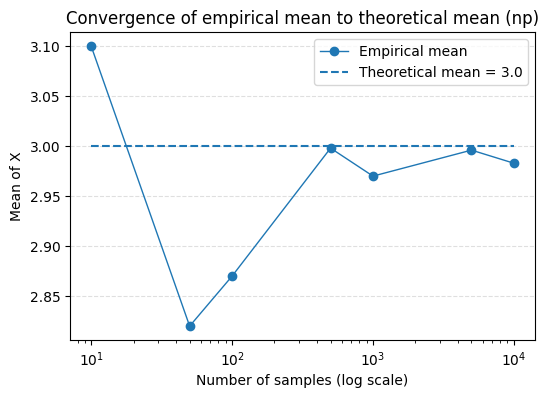

In [7]:
# === セル3: 収束確認（経験平均 -> 理論平均 np, SciPy版） ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n = 10
p = 0.3
theoretical_mean = binom.mean(n, p)  # n*p と同じ

sample_sizes = [10, 50, 100, 500, 1000, 5000, 10000]
empirical_means = []

rng = np.random.default_rng(12345)
for N in sample_sizes:
    samples = rng.binomial(n, p, size=N)  # 各サンプルは "成功回数"
    empirical_means.append(samples.mean())

plt.figure(figsize=(6, 4))
plt.plot(sample_sizes, empirical_means, marker="o", linewidth=1, label="Empirical mean")
plt.hlines(
    theoretical_mean,
    sample_sizes[0],
    sample_sizes[-1],
    linestyles="dashed",
    label=f"Theoretical mean = {theoretical_mean}",
)
plt.xscale("log")
plt.xlabel("Number of samples (log scale)")
plt.ylabel("Mean of X")
plt.title("Convergence of empirical mean to theoretical mean (np)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
save_figure_png(plt.gcf(), "binomial", "convergence.png")
plt.show()


## カテゴリ分布

Saved PNG: /home/njz/study_bayes/ベイズ推論による機械学習入門/Chapter2-基本的な確率分布/categorical/empirical_vs_theoretical.png


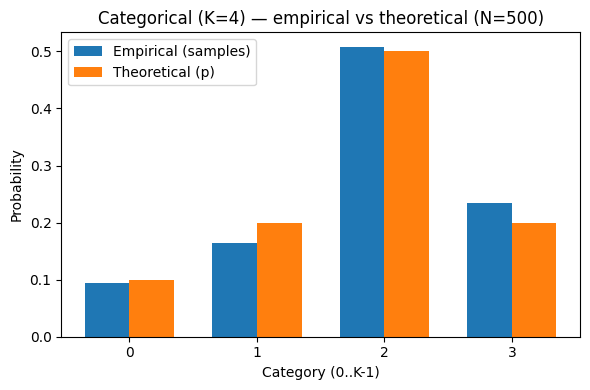

In [8]:
# === セル1: 単純な経験分布 vs 理論 PMF（Kカテゴリ） ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multinomial  # n=1 のときカテゴリ分布と同義

K = 4
p = np.array([0.1, 0.2, 0.5, 0.2])  # 合計1に注意
N = 500  # サンプル数

rng = np.random.default_rng(0)
# サンプリング：カテゴリは0..K-1 で表す
samples = rng.choice(np.arange(K), size=N, p=p)

# 経験確率
counts = np.bincount(samples, minlength=K)
emp_probs = counts / N

# 理論 PMF（各カテゴリの確率） — 単純に p ベクトル
theoretical = p

# 参考：ある観測がカテゴリ i のときの確率を scipy で計算する例
# one_hot ベクトルを作って multinomial.pmf に渡す（n=1）
# 例: 観測がカテゴリ2（index=1）の場合
one_hot = np.zeros(K, dtype=int)
one_hot[1] = 1
pmf_example = multinomial.pmf(one_hot, n=1, p=p)  # = p[1]

# 描画
x = np.arange(K)
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width / 2, emp_probs, width=width, label="Empirical (samples)")
ax.bar(x + width / 2, theoretical, width=width, label="Theoretical (p)")
ax.set_xticks(x)
ax.set_xlabel("Category (0..K-1)")
ax.set_ylabel("Probability")
ax.set_title(f"Categorical (K={K}) — empirical vs theoretical (N={N})")
ax.legend()
plt.tight_layout()
save_figure_png(fig, "categorical", "empirical_vs_theoretical.png")
plt.show()


Saved GIF: /home/njz/study_bayes/ベイズ推論による機械学習入門/Chapter2-基本的な確率分布/categorical/parameter_sweep.gif


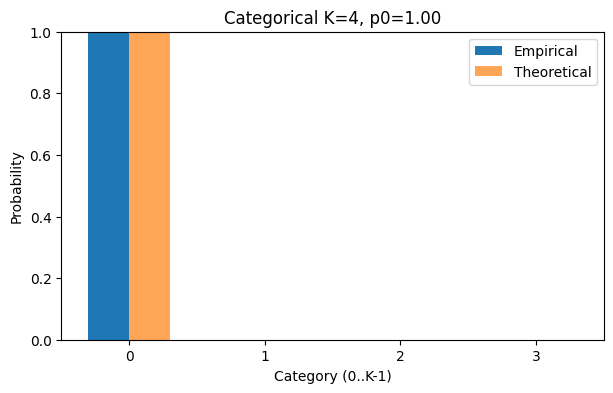

In [9]:
# === セル2: p をスイープするアニメーション（カテゴリ0の確率を変化、残りを均等に分配） ===
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

K = 4
# カテゴリ0の確率を0→1で動かす
p0_values = np.linspace(0.0, 1.0, 41)
N_per_frame = 1000

fig, ax = plt.subplots(figsize=(7, 4))
ax.set_ylim(0, 1.0)
ax.set_xlim(-0.5, K - 0.5)
ax.set_xticks(np.arange(K))
ax.set_xlabel("Category (0..K-1)")
ax.set_ylabel("Probability")
title = ax.set_title("")

bars_emp = ax.bar(np.arange(K) - 0.15, np.zeros(K), width=0.3, label="Empirical")
bars_theo = ax.bar(
    np.arange(K) + 0.15, np.zeros(K), width=0.3, alpha=0.7, label="Theoretical"
)
ax.legend()

rng = np.random.default_rng(42)


def make_p_vector(p0):
    # カテゴリ0に p0 を割り当て、残りを均等分配
    if p0 < 1.0:
        rem = 1.0 - p0
        others = np.repeat(rem / (K - 1), K - 1)
        return np.concatenate([[p0], others])
    vec = np.zeros(K)
    vec[0] = 1.0
    return vec


def update(frame):
    p0 = p0_values[frame]
    p_vec = make_p_vector(p0)
    # サンプリング（カテゴリとしてのサンプル）
    samples = rng.choice(np.arange(K), size=N_per_frame, p=p_vec)
    counts = np.bincount(samples, minlength=K)
    emp = counts / N_per_frame
    theo = p_vec
    for rect, h in zip(bars_emp, emp):
        rect.set_height(h)
    for rect, h in zip(bars_theo, theo):
        rect.set_height(h)
    title.set_text(f"Categorical K={K}, p0={p0:.2f}")
    return list(bars_emp) + list(bars_theo) + [title]


anim = FuncAnimation(fig, update, frames=len(p0_values), interval=150, blit=True)
save_animation_gif(anim, "categorical", "parameter_sweep.gif")
display(HTML(anim.to_jshtml()))


Saved PNG: /home/njz/study_bayes/ベイズ推論による機械学習入門/Chapter2-基本的な確率分布/categorical/convergence.png


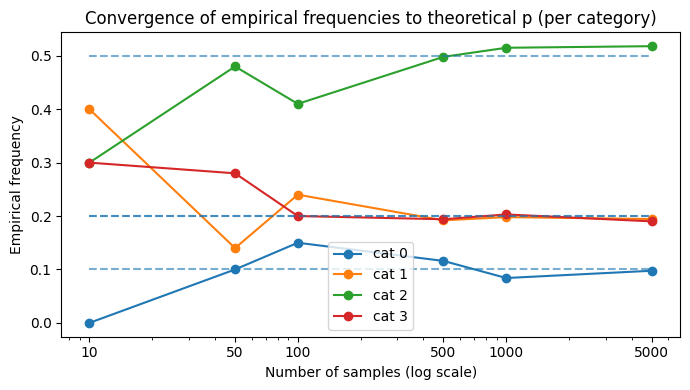

In [10]:
# === セル3: 収束プロット（各カテゴリの出現頻度が理論 p に近づく様子） ===
import numpy as np
import matplotlib.pyplot as plt

K = 4
p = np.array([0.1, 0.2, 0.5, 0.2])
sample_sizes = [10, 50, 100, 500, 1000, 5000]
rng = np.random.default_rng(1234)

emp_freqs = {k: [] for k in range(K)}
for N in sample_sizes:
    samples = rng.choice(np.arange(K), size=N, p=p)
    counts = np.bincount(samples, minlength=K)
    freqs = counts / N
    for k in range(K):
        emp_freqs[k].append(freqs[k])

fig, ax = plt.subplots(figsize=(7, 4))
for k in range(K):
    ax.plot(sample_sizes, emp_freqs[k], marker="o", label=f"cat {k}")
    ax.hlines(p[k], sample_sizes[0], sample_sizes[-1], linestyles="dashed", alpha=0.6)
ax.set_xscale("log")
ax.set_xlabel("Number of samples (log scale)")
ax.set_ylabel("Empirical frequency")
ax.set_title("Convergence of empirical frequencies to theoretical p (per category)")
ax.set_xticks(sample_sizes)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.legend()
plt.tight_layout()
save_figure_png(fig, "categorical", "convergence.png")
plt.show()


## 多項分布

In [11]:
# Multinomial PMF を Plotly で 3D 棒（直方体）表示する（Surface の代わり）
# 実行: Jupyter Notebook / Lab
import numpy as np
from scipy.stats import multinomial
import plotly.graph_objects as go

# ---- パラメータ（必要なら書き換え） ----
n = 5
p = np.array([0.2, 0.5, 0.3])
dx = 0.6  # 棒の x 幅
dy = 0.6  # 棒の y 幅
# -----------------------------------------

# outcome を列挙（k1,k2,k3）
outcomes = []
for k1 in range(n + 1):
    for k2 in range(n + 1 - k1):
        k3 = n - k1 - k2
        outcomes.append((k1, k2, k3))

# 各 outcome の PMF を計算
pmf = np.array([multinomial.pmf(k, n, p) for k in outcomes])
ymax = pmf.max()


# helper: 1つの直方体（cuboid）の頂点と三角形を返す
def cuboid_vertices_faces(xc, yc, h, dx=0.6, dy=0.6):
    x0 = xc - dx / 2
    x1 = xc + dx / 2
    y0 = yc - dy / 2
    y1 = yc + dy / 2
    z0 = 0.0
    z1 = h
    verts = [
        (x0, y0, z0),  # 0
        (x1, y0, z0),  # 1
        (x1, y1, z0),  # 2
        (x0, y1, z0),  # 3
        (x0, y0, z1),  # 4
        (x1, y0, z1),  # 5
        (x1, y1, z1),  # 6
        (x0, y1, z1),  # 7
    ]
    # 12 三角形 (i,j,k)
    faces = [
        (0, 1, 2),
        (0, 2, 3),  # bottom
        (4, 5, 6),
        (4, 6, 7),  # top
        (0, 1, 5),
        (0, 5, 4),  # side1
        (1, 2, 6),
        (1, 6, 5),  # side2
        (2, 3, 7),
        (2, 7, 6),  # side3
        (3, 0, 4),
        (3, 4, 7),  # side4
    ]
    return verts, faces


# 全 outcome から Mesh3d 用データを作る
xs, ys, zs = [], [], []
I, J, Kidx = [], [], []
intensity = []
hover_x, hover_y, hover_z, hover_text = [], [], [], []
vert_offset = 0

for (k1, k2, k3), h in zip(outcomes, pmf):
    if h <= 0:
        continue  # 高さゼロはスキップ
    verts, faces = cuboid_vertices_faces(k1, k2, h, dx=dx, dy=dy)
    for xv, yv, zv in verts:
        xs.append(xv)
        ys.append(yv)
        zs.append(zv)
        intensity.append(h)
    for a, b, c in faces:
        I.append(a + vert_offset)
        J.append(b + vert_offset)
        Kidx.append(c + vert_offset)
    vert_offset += len(verts)
    # ホバー用マーカー（棒の上）
    hover_x.append(k1)
    hover_y.append(k2)
    hover_z.append(h + 0.02)
    hover_text.append(f"({k1},{k2},{k3})<br>P={h:.6f}")

# Mesh3d trace（直方体群）
mesh = go.Mesh3d(
    x=xs,
    y=ys,
    z=zs,
    i=I,
    j=J,
    k=Kidx,
    intensity=intensity,
    colorscale="Viridis",
    intensitymode="vertex",
    flatshading=True,
    showscale=True,
    colorbar=dict(title="PMF"),
)

# ホバー表示用の透明マーカー（棒の上に置く）
scatter = go.Scatter3d(
    x=hover_x,
    y=hover_y,
    z=hover_z,
    mode="markers",
    marker=dict(size=2, color="rgba(0,0,0,0)"),
    hovertext=hover_text,
    hoverinfo="text",
    showlegend=False,
)

fig = go.Figure(data=[mesh, scatter])

fig.update_layout(
    title=f"Multinomial PMF as 3D bars (n={n}, p={p})",
    scene=dict(
        xaxis=dict(title="k1", nticks=n + 1, range=[-0.5, n + 0.5]),
        yaxis=dict(title="k2", nticks=n + 1, range=[-0.5, n + 0.5]),
        zaxis=dict(title="P(X=k)", range=[0, ymax * 1.15]),
    ),
    width=900,
    height=750,
)

save_plotly_png(fig, "multinomial_plotly", "surface.png")
fig.show()


/tmp/ipykernel_36712/3279554331.py:67: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




Saved PNG: /home/njz/study_bayes/ベイズ推論による機械学習入門/Chapter2-基本的な確率分布/multinomial_plotly/surface.png


In [12]:
# Plotly: Multinomial の 3D 棒（直方体）アニメーション (p0,p1 グリッド)
# 修正版：hover テキストのフォーマットエラーを修正済み
import numpy as np
from scipy.stats import multinomial
import plotly.graph_objects as go

# ---------- ユーザー調整パラメータ ----------
n = 8                # 試行ごとの合計カウント（大きいと棒が増える）
grid_size = 9        # p0,p1 の分解数（例 9 -> 0.0,0.125,...,1.0 に近い）
K = 3                # カテゴリ数 (ここは3固定)
dx = 0.6             # 棒の x 幅
dy = 0.6             # 棒の y 幅
# ------------------------------------------

# outcome を列挙（k1,k2,k3）
outcomes = []
for k1 in range(n+1):
    for k2 in range(n+1-k1):
        k3 = n - k1 - k2
        outcomes.append((k1, k2, k3))

labels = [f"({k1},{k2},{k3})" for (k1, k2, k3) in outcomes]

# p グリッド (p0,p1) で p2 = 1 - p0 - p1 >= 0 の点だけ採用
p_vals = np.linspace(0.0, 1.0, grid_size)
param_points = []
for p0 in p_vals:
    for p1 in p_vals:
        p2 = 1.0 - p0 - p1
        if p2 >= -1e-12:
            p2 = max(0.0, p2)
            param_points.append((round(p0,8), round(p1,8), round(p2,8)))

# 事前計算: 各フレームの pmf と y 軸最大値（スケール固定用）
frames_data = []
ymax = 0.0
for p_vec in param_points:
    p = np.array(p_vec)
    pmf = np.array([multinomial.pmf(k, n, p) for k in outcomes])
    frames_data.append((p, pmf))
    ymax = max(ymax, pmf.max())

# helper: 1つの直方体の頂点と三角形（インデックス）を返す
def cuboid_vertices_faces(xc, yc, h, dx=0.6, dy=0.6):
    # 8 頂点
    x0 = xc - dx/2; x1 = xc + dx/2
    y0 = yc - dy/2; y1 = yc + dy/2
    z0 = 0.0; z1 = h
    verts = [
        (x0, y0, z0),  #0
        (x1, y0, z0),  #1
        (x1, y1, z0),  #2
        (x0, y1, z0),  #3
        (x0, y0, z1),  #4
        (x1, y0, z1),  #5
        (x1, y1, z1),  #6
        (x0, y1, z1),  #7
    ]
    # 12 三角形 (i,j,k)
    faces = [
        (0,1,2), (0,2,3),     # bottom
        (4,5,6), (4,6,7),     # top
        (0,1,5), (0,5,4),     # side1
        (1,2,6), (1,6,5),     # side2
        (2,3,7), (2,7,6),     # side3
        (3,0,4), (3,4,7),     # side4
    ]
    return verts, faces

# 指定のフレーム用に Mesh3d データ（x,y,z, i,j,k, intensity）を作る
def make_mesh_for_pmf(outcomes, pmf, dx=dx, dy=dy):
    xs, ys, zs = [], [], []
    I, J, Kidx = [], [], []
    intensity = []
    vert_offset = 0
    # 各 outcome ごとに cuboid を作る
    for (k1,k2,k3), h in zip(outcomes, pmf):
        if h <= 0:
            continue  # 高さゼロの棒は作らない（描画効率化）
        verts, faces = cuboid_vertices_faces(k1, k2, h, dx=dx, dy=dy)
        for (xv, yv, zv) in verts:
            xs.append(xv); ys.append(yv); zs.append(zv)
            intensity.append(h)  # 頂点ごとの強度は高さ（pmf）
        # faces を三角形リストに追加（インデックス補正）
        for (a,b,c) in faces:
            I.append(a + vert_offset)
            J.append(b + vert_offset)
            Kidx.append(c + vert_offset)
        vert_offset += len(verts)
    return dict(x=xs, y=ys, z=zs, i=I, j=J, k=Kidx, intensity=intensity)

# 最初のフレームを作る
p0, pmf0 = frames_data[0]
mesh0 = make_mesh_for_pmf(outcomes, pmf0, dx=dx, dy=dy)

# 初期の Mesh3d trace
mesh_trace = go.Mesh3d(
    x=mesh0['x'], y=mesh0['y'], z=mesh0['z'],
    i=mesh0['i'], j=mesh0['j'], k=mesh0['k'],
    intensity=mesh0['intensity'],
    colorscale='Viridis',
    intensitymode='vertex',
    showscale=True,
    colorbar=dict(title='PMF'),
    flatshading=True,
    name='bars'
)

# 上にホバーテキスト用の scatter3d（棒の頂点中央で表示）
top_x = []
top_y = []
top_z = []
for (k1,k2,k3), h in zip(outcomes, pmf0):
    if h <= 0: continue
    top_x.append(k1)
    top_y.append(k2)
    top_z.append(h + 0.02)  # 棒の上に少し空けてテキスト

scatter0 = go.Scatter3d(
    x=top_x, y=top_y, z=top_z,
    mode='markers',
    marker=dict(size=2, color='rgba(0,0,0,0)'),
    hovertext=[f"({k1},{k2},{k3})<br>P={h:.6f}" for (k1,k2,k3), h in zip(outcomes, pmf0) if h>0],
    hoverinfo='text',
    showlegend=False
)

# フレーム作成 (mesh + scatter 両方をフレームに入れる)
frames = []
for idx, (pvec, pmf) in enumerate(frames_data):
    meshd = make_mesh_for_pmf(outcomes, pmf, dx=dx, dy=dy)
    # scatter のテキストも作る
    sx, sy, sz, stext = [], [], [], []
    for (k1,k2,k3), h in zip(outcomes, pmf):
        if h <= 0: continue
        sx.append(k1); sy.append(k2); sz.append(h + 0.02)
        stext.append(f"({k1},{k2},{k3})<br>P={h:.6f}")
    frame_mesh = go.Mesh3d(
        x=meshd['x'], y=meshd['y'], z=meshd['z'],
        i=meshd['i'], j=meshd['j'], k=meshd['k'],
        intensity=meshd['intensity'],
        colorscale='Viridis', intensitymode='vertex', flatshading=True, showscale=False
    )
    frame_scatter = go.Scatter3d(
        x=sx, y=sy, z=sz, mode='markers',
        marker=dict(size=2, color='rgba(0,0,0,0)'),
        hovertext=stext, hoverinfo='text', showlegend=False
    )
    frames.append(go.Frame(data=[frame_mesh, frame_scatter], name=str(idx),
                           layout=go.Layout(title_text=f"n={n}, p={pvec}")))

# Figure 構築
fig = go.Figure(data=[mesh_trace, scatter0], frames=frames)

# スライダー用ステップ
slider_steps = []
for i, (pvec, _) in enumerate(frames_data):
    label = f"p0={pvec[0]:.2f},p1={pvec[1]:.2f}"
    step = dict(method="animate",
                args=[[str(i)], dict(mode="immediate", frame=dict(duration=0, redraw=True), transition=dict(duration=0))],
                label=label)
    slider_steps.append(step)

fig.update_layout(
    title=f"Multinomial PMF as 3D bars (n={n})",
    scene=dict(
        xaxis=dict(title='k1', nticks=n+1, range=[-0.5, n+0.5]),
        yaxis=dict(title='k2', nticks=n+1, range=[-0.5, n+0.5]),
        zaxis=dict(title='P(X=k)', range=[0, ymax * 1.05])
    ),
    width=1000, height=800,
    updatemenus=[dict(type="buttons", showactive=False,
                      y=1.05, x=1.02, xanchor="right", yanchor="top",
                      pad=dict(t=0,r=10),
                      buttons=[dict(label="Play",
                                    method="animate",
                                    args=[None, dict(frame=dict(duration=300, redraw=True), fromcurrent=True, transition=dict(duration=0))]),
                               dict(label="Pause",
                                    method="animate",
                                    args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate", transition=dict(duration=0))])])],
    sliders=[dict(active=0, pad={"t":60}, steps=slider_steps, x=0.05, len=0.9)]
)

save_plotly_html(fig, "multinomial_plotly", "surface_animation.html")
save_plotly_animation_preview(fig, "multinomial_plotly", "surface_animation_preview.png")
fig.show()


Saved HTML: /home/njz/study_bayes/ベイズ推論による機械学習入門/Chapter2-基本的な確率分布/multinomial_plotly/surface_animation.html


/tmp/ipykernel_36712/3279554331.py:67: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




Saved PNG: /home/njz/study_bayes/ベイズ推論による機械学習入門/Chapter2-基本的な確率分布/multinomial_plotly/surface_animation_preview.png


Saved PNG: /home/njz/study_bayes/ベイズ推論による機械学習入門/Chapter2-基本的な確率分布/multinomial_plotly/convergence.png


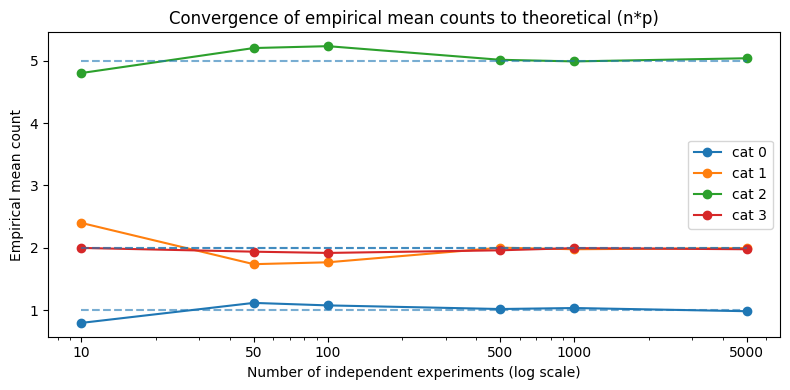

In [13]:
# セル3: 収束確認（複数回独立実験を行い、平均カウントが n*p に近づく様子）
import numpy as np
import matplotlib.pyplot as plt

K = 4
n = 10
p = np.array([0.1, 0.2, 0.5, 0.2])
# 1つのサイズは「独立に行う multinomial の回数」
sample_sizes = [10, 50, 100, 500, 1000, 5000]
rng = np.random.default_rng(1234)

emp_means = {k: [] for k in range(K)}
for N in sample_sizes:
    # N 回の独立試行を行う（各試行は n 回のカテゴリ割当）
    samples = rng.multinomial(n, p, size=N)  # shape (N, K)
    mean_counts = samples.mean(axis=0)  # 平均カウント (per category)
    for k in range(K):
        emp_means[k].append(mean_counts[k])

theo_mean = n * p

fig, ax = plt.subplots(figsize=(8, 4))
for k in range(K):
    ax.plot(sample_sizes, emp_means[k], marker="o", label=f"cat {k}")
    ax.hlines(
        theo_mean[k], sample_sizes[0], sample_sizes[-1], linestyles="dashed", alpha=0.6
    )
ax.set_xscale("log")
ax.set_xlabel("Number of independent experiments (log scale)")
ax.set_ylabel("Empirical mean count")
ax.set_title("Convergence of empirical mean counts to theoretical (n*p)")
ax.set_xticks(sample_sizes)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.legend()
plt.tight_layout()
save_figure_png(fig, "multinomial_plotly", "convergence.png")
plt.show()


## ポアソン分布

Saved PNG: /home/njz/study_bayes/ベイズ推論による機械学習入門/Chapter2-基本的な確率分布/poisson/empirical_vs_theoretical.png


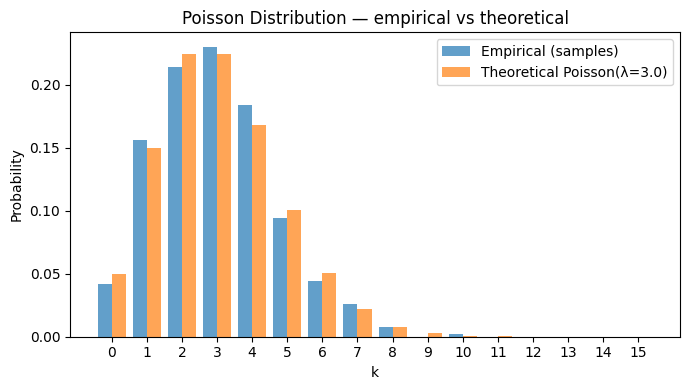

In [14]:
# === セル1: Poisson の理論 PMF（SciPy）とサンプリング例 ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# パラメータ
lam = 3.0  # lambda (平均発生率)
k_max = 15  # 描画する最大 k（tail は切る）

k = np.arange(0, k_max + 1)
pmf = poisson.pmf(k, mu=lam)

# サンプリング
rng = np.random.default_rng(0)
samples = rng.poisson(lam, size=500)  # NumPy の poisson RNG

# 経験分布（サンプルのヒストグラム）
counts = np.bincount(samples, minlength=k_max + 1)[: k_max + 1]
emp_probs = counts / counts.sum()

plt.figure(figsize=(7, 4))
plt.bar(k - 0.2, emp_probs, width=0.4, label="Empirical (samples)", alpha=0.7)
plt.bar(k + 0.2, pmf, width=0.4, label=f"Theoretical Poisson(λ={lam})", alpha=0.7)
plt.xlabel("k")
plt.ylabel("Probability")
plt.title("Poisson Distribution — empirical vs theoretical")
plt.xticks(k)
plt.legend()
plt.tight_layout()
save_figure_png(plt.gcf(), "poisson", "empirical_vs_theoretical.png")
plt.show()


Saved GIF: /home/njz/study_bayes/ベイズ推論による機械学習入門/Chapter2-基本的な確率分布/poisson/parameter_sweep.gif


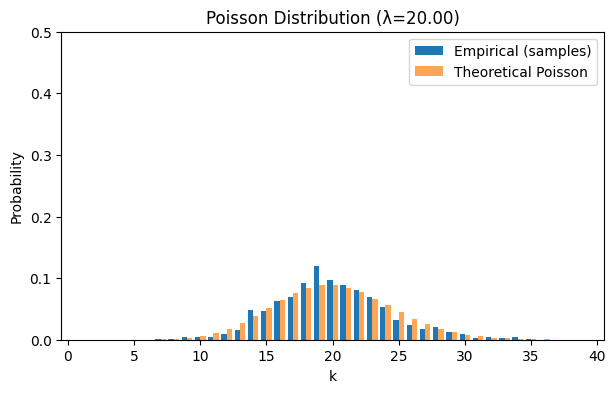

In [15]:
# === セル2: λ をスイープするアニメーション（Notebook 内表示） ===
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.stats import poisson

lam_values = np.linspace(0.1, 20.0, 40)  # lambda を変化
k_max = 40
N_per_frame = 800  # 各フレームでのサンプル数（経験分布）

fig, ax = plt.subplots(figsize=(7, 4))
k = np.arange(0, k_max + 1)
bars_emp = ax.bar(
    k - 0.2, np.zeros_like(k, dtype=float), width=0.4, label="Empirical (samples)"
)
bars_theo = ax.bar(
    k + 0.2,
    np.zeros_like(k, dtype=float),
    width=0.4,
    alpha=0.7,
    label="Theoretical Poisson",
)
ax.set_xlabel("k")
ax.set_ylabel("Probability")
ax.set_title("")
ax.set_xlim(-0.5, k_max + 0.5)
ax.set_ylim(0, 0.5)
ax.legend()

rng = np.random.default_rng(123)


def update(frame):
    lam = lam_values[frame]
    samples = rng.poisson(lam, size=N_per_frame)
    counts = np.bincount(samples, minlength=k_max + 1)[: k_max + 1]
    emp = counts / counts.sum()
    theo = poisson.pmf(k, mu=lam)
    for rect, h in zip(bars_emp, emp):
        rect.set_height(h)
    for rect, h in zip(bars_theo, theo):
        rect.set_height(h)
    ax.set_title(f"Poisson Distribution (λ={lam:.2f})")
    return list(bars_emp) + list(bars_theo)


anim = FuncAnimation(fig, update, frames=len(lam_values), interval=150, blit=True)
save_animation_gif(anim, "poisson", "parameter_sweep.gif")
display(HTML(anim.to_jshtml()))


λでかくすると正規分布っぽくなるんやね

Saved PNG: /home/njz/study_bayes/ベイズ推論による機械学習入門/Chapter2-基本的な確率分布/poisson/convergence.png


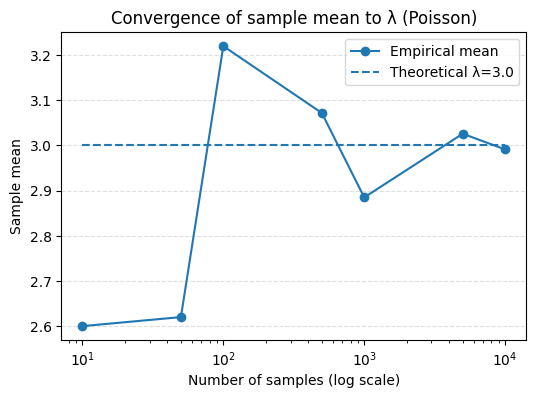

In [16]:
# === セル3: 収束プロット（経験平均 -> λ） ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

lam_fixed = 3.0
sample_sizes = [10, 50, 100, 500, 1000, 5000, 10000]
emp_means = []

rng = np.random.default_rng(2024)
for N in sample_sizes:
    samples = rng.poisson(lam_fixed, size=N)
    emp_means.append(samples.mean())

plt.figure(figsize=(6, 4))
plt.plot(sample_sizes, emp_means, marker="o", label="Empirical mean")
plt.hlines(
    lam_fixed,
    sample_sizes[0],
    sample_sizes[-1],
    linestyles="dashed",
    label=f"Theoretical λ={lam_fixed}",
)
plt.xscale("log")
plt.xlabel("Number of samples (log scale)")
plt.ylabel("Sample mean")
plt.title("Convergence of sample mean to λ (Poisson)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
save_figure_png(plt.gcf(), "poisson", "convergence.png")
plt.show()
